# Perceptron Using Pytorch With SGD Implemented

In [1]:
%%capture
!pip install matplotalt

In [2]:
try:
    import torch as t
    import torch.nn as tnn
except ImportError:
    print("Colab users: pytorch comes preinstalled. Select Change Runtime > T4 GPU")
    print("Local users: Please install pytorch for your hardware using instructions from here: https://pytorch.org/get-started/locally/")
    print("ACG users: Please follow instructions here: https://vikasdhiman.info/ECE490-Neural-Networks/posts/0000-00-06-acg-slurm-jupyter/")

    raise

if t.cuda.is_available():
    DEVICE="cuda"
elif t.mps.is_available():
    DEVICE="mps"
else:
    DEVICE="cpu"

DTYPE = t.get_default_dtype()

1. Dataset
2. Model
3. Loss
4. Training algorithm

## Dataset

In [3]:
## Doing it the Pytorch way without using our custom feature extraction
import torch
import torch.nn
import torch.optim
import torchvision
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

#torch.manual_seed(17) # Only use during debugging

In [4]:
# Modify MNIST to consider only zero or one classes
class MNISTFilterZeroOne(torchvision.datasets.MNIST):
    PIXEL_MEAN = 0.5 # made up
    PIXEL_STD = 0.5 # made up
    def __init__(self, root, **kwargs):
        # passes everything to the parent class
        super().__init__(root, **kwargs)
        # Parent class source is here: https://docs.pytorch.org/vision/stable/_modules/torchvision/datasets/mnist.html#MNIST
        # Parent class downloads and loads data into self.data and self.targets
        
        # We use boolean array indexing to filter the classes
        # Learn about it here https://numpy.org/doc/stable/user/basics.indexing.html#boolean-array-indexing
        either_zero_or_one = (self.targets == 0) | (self.targets == 1)
        filtered_targets = self.targets[either_zero_or_one]
        filtered_data = self.data[either_zero_or_one]
        
        # Overwrite the self.data and self.targets and let parent class take are of the rest
        self.data = filtered_data
        self.targets = filtered_targets * 2 - 1 # make it -1, 1
    def __getitem__(self, idx):
        data, target = super().__getitem__(idx)
        data2 = (data - self.PIXEL_MEAN) / self.PIXEL_STD
        return data2, target

In [5]:
# Getting the dataset, the Pytorch way
# Class wrappers over the dataset: train and test
all_training_data = MNISTFilterZeroOne(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

# Sacred, only use it for evaluation; cannot use it in any part of the
# training decision making
# Data contamination
test_data = MNISTFilterZeroOne(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [6]:
training_data, validation_data = torch.utils.data.random_split(all_training_data, [0.9, 0.1]) # spliting 90%, 10%

## Hyper Parameters

In [7]:
# Hyper parameters
learning_rate = 1e-3 # controls how fast the gradient descents, descens
batch_size = 64 # SGD batch size
epochs = 10 # How many times I will go over the full training dataset
momentum = 0.9 # SGD with momentum \beta

## Model

In [8]:
# Wraper class to load data from the harddisk to the memory
# def __iter__(): return the current batch
# torch.random.shuffle
training_dataloader = DataLoader(training_data, shuffle=True, batch_size=batch_size)
validation_dataloader = DataLoader(validation_data,  batch_size=batch_size)
test_dataloader = DataLoader(test_data,  batch_size=batch_size)

In [9]:
import math
# TODO:
# Define model = ?
# All pytorch models are inherited from torch.nn.Module
# 1. it keeps track of all the weights and biases that need to be trained.
# 2. it provide gradients and puts them cleanly on each weight.grad, bias.grad

class Perceptron(torch.nn.Module):
    # constructor
    def __init__(self, nclasses=2, input_size=28*28):
        super().__init__()

        # self.l1 is this an object of class e
        # if self.l1 is torch.nn.Module, this class will looking inside it recursively for more Paramters
        # self.l1 as an object of list class
        # self.l1 = {torch.nn.Linear()} # these parameters will never betorch.nn.Parameter, or torch.nn.Modul
        # Define the layers
        # MNIST image is 28x28 pixels -> 28*28 = input_size (approx 900) vector
        # Random initialization of paramters
        assert nclasses == 2
        w = (torch.rand(input_size) - 0.5) * 2 / input_size
        b = (torch.rand(1) - 0.5 ) * 2
        self.w = torch.nn.parameter.Parameter(w) # tell pytorch to minimize this during opt
        self.b = torch.nn.parameter.Parameter(b) # tell pytorch to minimize this during opt

    # f = MLPNetwork(...)
    # f(x)
    # def __call__(self, x)
    # input data to the network
    def forward(self, X):
        # X.shape = (batch, 1, 28, 28) # Batch, channels, height, width
        X = torch.flatten(X, start_dim=-3, end_dim=-1)
        # X.shape = (batch, 1, 28*28)
        # self.w.shape = (28*28)
        # either return (self.w @ X.T + self.b)
        # OR:
        return X @ self.w + self.b

model = Perceptron()
def yhat_to_class_label(yhat):
    return torch.where(yhat > 0, +1, -1)

# Loss function

In [10]:
def loss(yhat, y):
    return torch.maximum(- y * yhat, torch.zeros_like(y)).sum() / y.shape[0]

## Training

In [11]:
# Define optimizer
# Define learning_rate scheduler
# model.parameters() provides a list of trainable parameters as torch.Tensors
# optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)

class SGD:
  "We implement our on SGD"
  def __init__(self, parameters, lr=0.1,  momentum=0.9):
    self.parameters = list(parameters) # also called the weights as torch.Tensors
    self.lr = lr
    self.beta  = momentum
    self.momentum = [None for  param in self.parameters] # m_t same size weights w

  def zero_grad(self):
    " Set all the gradients to zero"
    for param  in  self.parameters:
      if param.grad is not None:
        param.grad[:] = 0


  def step(self):
    """ Updating all the weights according to the optimization algo

    For SGD:
    mₜ₊₁ = β * mₜ + (1-β) * ∂L/∂w
    wₜ₊₁ = wₜ - αₜ * mₜ₊₁
    
    where wₜ is param and ∂L/∂w is param.grad
    """
    β =  self.beta
    αₜ =  self.lr
    with t.no_grad(): # disable gradients
        for idx, (param, m) in enumerate(zip(self.parameters, self.momentum)):
            if m is None: # initial momentum term if required
                m = t.zeros_like(param, requires_grad=False) #
                self.momentum[idx] = m
            else:
                # We do not do this:
                # m = β * m + (1-β) * param.grad
                # param = param - αₜ * m
                #
                # Why: if we do normal math operations, on the left hand side, 
                # this will create new torch.tensor, but we want the same Tensor
                # that is assigned self.momentum[idx] = mo and the same param that is part of the 
                # Tensor graph.
                #
                # Instead, we use in-place tensor operations
                # Read: https://docs.pytorch.org/docs/stable/generated/torch.Tensor.mul_.html
                m.mul_(β)  # m1 =  β * mₜ
            
            # Read: https://docs.pytorch.org/docs/stable/generated/torch.Tensor.add_.html
            m.add_(param.grad) # mₜ₊₁ = m1 + param.grad
            param.add_(m, alpha=-αₜ) # wₜ₊₁ = wₜ - αₜ * mₜ₊₁

optimizer = SGD(model.parameters(), lr=learning_rate, momentum=momentum)

#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min")

In [12]:
def loss_and_accuracy(model, loss, validation_dataloader, device=DEVICE):
    # Validation loop
    validation_size = len(validation_dataloader.dataset)
    num_batches = len(validation_dataloader)
    test_loss, correct = 0, 0

    model.eval()
    with torch.no_grad():
        for X, y in validation_dataloader:
            X = X.to(device)
            y = y.to(device)
            pred = model(X)
            test_loss += loss(pred, y).item()
            correct += (yhat_to_class_label(pred) == y).type(DTYPE).sum().item()
    model.train()
    test_loss /= num_batches
    correct /= validation_size
    return test_loss, correct

In [13]:
def train(model, loss, training_dataloader, validation_dataloader, device=DEVICE):
    model.to(device)
    train_losses = []
    valid_losses = []
    
    valid_loss, correct = loss_and_accuracy(model, loss, validation_dataloader, device=device)
    #valid_losses.append(valid_loss)
    print(f"Validation Error {0}/{epochs}: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {valid_loss:>8f} \n")
    
    model.train()
    for t in range(epochs):
        # Train loop
        training_size = len(training_dataloader.dataset)
        for batch, (X, y) in enumerate(training_dataloader):
            X = X.to(device)
            y = y.to(device)
            # Compute prediction and loss
            pred = model(X)
            loss_t = loss(pred, y)

            # Backpropagation
            optimizer.zero_grad()
            loss_t.backward() # gradient
            optimizer.step()  # updating

        valid_loss, correct = loss_and_accuracy(model, loss, validation_dataloader, device=device)
        #scheduler.step(valid_loss)
        valid_losses.append(valid_loss)

        loss_t = loss_t.item()
        print(f"loss: {loss_t:>7f}", end="\r")
        train_losses.append(loss_t)

        print(f"Validation Error {t+1}/{epochs}: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {valid_loss:>8f} \n")
    return model, train_losses, valid_losses

trained_model, train_losses, valid_losses = train(model, loss, training_dataloader, validation_dataloader)

test_loss, correct = loss_and_accuracy(model, loss, test_dataloader)
print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

Validation Error 0/10: 
 Accuracy: 46.0%, Avg loss: 0.111104 

Validation Error 1/10: 
 Accuracy: 99.7%, Avg loss: 0.000680 

Validation Error 2/10: 
 Accuracy: 99.7%, Avg loss: 0.000520 

Validation Error 3/10: 
 Accuracy: 99.6%, Avg loss: 0.000483 

Validation Error 4/10: 
 Accuracy: 99.7%, Avg loss: 0.000321 

Validation Error 5/10: 
 Accuracy: 99.7%, Avg loss: 0.000309 

Validation Error 6/10: 
 Accuracy: 99.7%, Avg loss: 0.000266 

Validation Error 7/10: 
 Accuracy: 99.8%, Avg loss: 0.000186 

Validation Error 8/10: 
 Accuracy: 99.7%, Avg loss: 0.000147 

Validation Error 9/10: 
 Accuracy: 99.7%, Avg loss: 0.000184 

Validation Error 10/10: 
 Accuracy: 99.8%, Avg loss: 0.000136 

Test Error: 
 Accuracy: 99.9%, Avg loss: 0.000062 



KeyError: 'data'

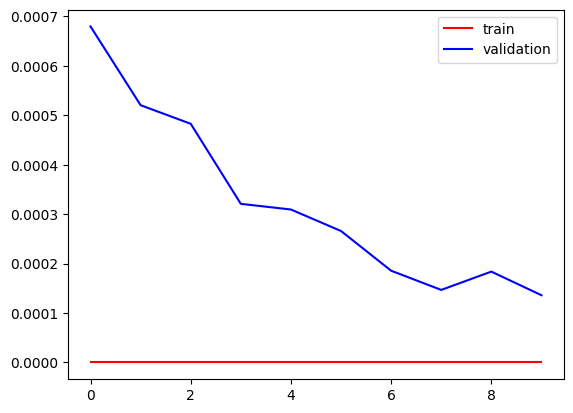

In [14]:
import matplotlib.pyplot as plt
from matplotalt import show_with_alt
plt.plot(train_losses, 'r', label='train')
plt.plot(valid_losses, 'b', label='validation')
plt.legend()
show_with_alt()

In [ ]:
X, _ = next(iter(test_dataloader))
X.shape

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(X[0, 0])

In [ ]:
print("The predicted image label is ", model(X.to(DEVICE)).argmax(dim=-1)[0].item())